#Analysis Objectives
- Analyse the company is overall business performance.
- Identify the most popular restaurants.
- Uunderstand customer ordering behavior.
- Evaluate delivery speed and efficiency.
- Analyze customer rstings and satisfaction.
- Compare the payment methods used by customers.
- Create visualizations to analyze sales performance and examine the relationship between quantity sold and price.

#Import Libraries & Load Dataset
- Before analyzing data , we need to import the tools that will help us work the dataset.
- Common Python libraries used in data analysis include:
*  Pandas
*  NumPy
* Matplotlib

**My Task** :
1. Import all required libraries.
2. Load the dataset.
3. Display the first few rows.
4. Confirm that the dataset loaded successfully.




In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
data=pd.read_csv("/content/Food_Delivery.csv")
data.head()

,order_id,customer_id,restaurant,city,order_date,delivery_time_minutes,item,quantity,price,discount,payment_method,rating
0,1,1102,Kebab House,alex,2024-01-01 00:00:00,40.0,Kebab,4,265,13,Wallet,1.0
1,2,1435,Sushi World,alex,2024-01-01 01:00:00,30.0,Pasta,2,241,5,Card,3.0
2,3,1860,Burger Town,Cairo,2024-01-01 02:00:00,NaN,Pasta,3,240,13,Wallet,2.0
3,4,1270,Sushi World,cairo,2024-01-01 03:00:00,43.0,Kebab,3,269,16,Wallet,2.0
4,5,1106,Burger Town,Cairo,2024-01-01 04:00:00,12.0,Pizza,1,129,17,Cash,2.0


#Dataset Understanding
My Task

Explore the dataset and document:
Dataset Shape
Identify:
- Number of rows
- Number of columns
- Dataset Structure

Review:
- Column names
- Data types
- Initial Dataset Review

Examine:
- Sample records
- General observations
- Potential issues that may require cleaning later

In [69]:
data.shape

(2050, 12)

**Rows** = 2050

**columns** = 12


#Column Description
| Column        | Description                        

order_id        | Unique identifier for each order                  
customer_id| Unique identifier for each customer                      
restaurant  | Name of the resturant where the order was placed  
city        | City where the order was
delivered

price      | Total order price before discount              
discount    | Discount applied to the order                     
rating      | Customer rating (1-5)   
order_date  | Date and time when the order was placed    
delivery_time_minutes | Delivery duration in minutes               
item        | Food item ordered                          
quantity    | Number of items ordered                  
payment_method       | Payment method used (Cash, Card, or Wallet)




### Data Types for Each Column


In [70]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2050 entries, 0 to 2049
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               2050 non-null   int64  
 1   customer_id            2050 non-null   int64  
 2   restaurant             2050 non-null   object 
 3   city                   1947 non-null   object 
 4   order_date             2050 non-null   object 
 5   delivery_time_minutes  1943 non-null   float64
 6   item                   2050 non-null   object 
 7   quantity               2050 non-null   int64  
 8   price                  2050 non-null   int64  
 9   discount               2050 non-null   int64  
 10  payment_method         2050 non-null   object 
 11  rating                 1945 non-null   float64
dtypes: float64(2), int64(5), object(5)
memory usage: 192.3+ KB


#Initial Dataset Review
### Initial Observations

- The dataset contains food delivery orders with various food items
- It includes information about customers, restaurants, cities, prices, discounts, payment methods, delivery time, and customer ratings
- Each customer has a unique customer ID, and each order has a unique order ID
- The dataset includes discount information that can be used to analyze promotional offers
- The order_date column may need to be converted to the datetime data type for time-based analysis
- The rating column contains some missing values that may require cleaning before analysis

In [71]:
data.head()

,order_id,customer_id,restaurant,city,order_date,delivery_time_minutes,item,quantity,price,discount,payment_method,rating
0,1,1102,Kebab House,alex,2024-01-01 00:00:00,40.0,Kebab,4,265,13,Wallet,1.0
1,2,1435,Sushi World,alex,2024-01-01 01:00:00,30.0,Pasta,2,241,5,Card,3.0
2,3,1860,Burger Town,Cairo,2024-01-01 02:00:00,NaN,Pasta,3,240,13,Wallet,2.0
3,4,1270,Sushi World,cairo,2024-01-01 03:00:00,43.0,Kebab,3,269,16,Wallet,2.0
4,5,1106,Burger Town,Cairo,2024-01-01 04:00:00,12.0,Pizza,1,129,17,Cash,2.0


In [72]:
data.tail()

,order_id,customer_id,restaurant,city,order_date,delivery_time_minutes,item,quantity,price,discount,payment_method,rating
2045,1380,1167,Kebab House,CAIRO,2024-02-27 11:00:00,18.0,Sushi,1,232,10,Cash,4.0
2046,313,1836,Sushi World,cairo,2024-01-14 00:00:00,NaN,Pasta,3,239,17,Wallet,2.0
2047,118,1748,Sushi World,Alex,2024-01-05 21:00:00,46.0,Kebab,2,162,19,Cash,5.0
2048,777,1880,Kebab House,CAIRO,2024-02-02 08:00:00,40.0,Pasta,2,202,19,Wallet,2.0
2049,23,1769,Pizza Hub,cairo,2024-01-01 22:00:00,40.0,Pizza,2,135,16,Wallet,NaN


In [73]:
data.describe()

,order_id,customer_id,delivery_time_minutes,quantity,price,discount,rating
count,2050.000000,2050.000000,1943.000000,2050.000000,2050.000000,2050.000000,1945.000000
mean,1000.057073,1499.454634,35.249614,2.650244,172.146829,14.497561,2.972751
std,577.001897,294.397792,18.997235,2.402641,71.659016,8.451408,1.412677
min,1.000000,1000.000000,-3.000000,1.000000,50.000000,0.000000,1.000000
25%,501.250000,1232.000000,26.000000,1.000000,111.000000,7.000000,2.000000
50%,1001.500000,1505.000000,35.000000,3.000000,170.000000,15.000000,3.000000
75%,1497.750000,1761.000000,43.000000,4.000000,233.750000,22.000000,4.000000
max,2000.000000,1998.000000,292.000000,41.000000,299.000000,29.000000,5.000000


#Data Quality Assessment

In [74]:
print(data.duplicated())

0       False
1       False
2       False
3       False
4       False
        ...  
2045     True
2046     True
2047     True
2048     True
2049     True
Length: 2050, dtype: bool


In [75]:
print(data.duplicated().sum())

50


The dataset contains 50 duplicate records

In [76]:
print(data.isnull().sum())

order_id                   0
customer_id                0
restaurant                 0
city                     103
order_date                 0
delivery_time_minutes    107
item                       0
quantity                   0
price                      0
discount                   0
payment_method             0
rating                   105
dtype: int64


**Missing Values Assessment** **:**

* The city column contains 103 missing values
*  The delivery_time_minutes column contains 107 missing values
*  The rating column contains 105 missing values
* All other columns contain no missing values






#Handle Duplicate Records
Duplicate Assessment

The dataset contains 50 duplicate records.

In [77]:
print(data[data.duplicated()])

      order_id  customer_id   restaurant   city           order_date  \
2000      1283         1517    Pizza Hub   Giza  2024-02-23 10:00:00   
2001       460         1515    Pizza Hub    NaN  2024-01-20 03:00:00   
2002      1976         1287  Kebab House  Cairo  2024-03-23 07:00:00   
2003      1100         1305  Sushi World  cairo  2024-02-15 19:00:00   
2004       264         1607    Pizza Hub   alex  2024-01-11 23:00:00   
2005      1162         1092  Pasta Point   alex  2024-02-18 09:00:00   
2006       732         1601  Burger Town  CAIRO  2024-01-31 11:00:00   
2007        56         1831  Burger Town  CAIRO  2024-01-03 07:00:00   
2008      1268         1145  Pasta Point  CAIRO  2024-02-22 19:00:00   
2009      1760         1914  Sushi World   Alex  2024-03-14 07:00:00   
2010      1895         1068  Sushi World  CAIRO  2024-03-19 22:00:00   
2011       756         1688  Pasta Point  cairo  2024-02-01 11:00:00   
2012        81         1508  Pasta Point  Cairo  2024-01-04 08:0

#Cleaning Process

Duplicate records were removed using the drop_duplicates() function

In [78]:
data.drop_duplicates(inplace=True)

#**Decision and Justification**

The duplicate records were removed because they represented repeated entries that could distort the analysis results, such as the total number of orders, revenue, and customer behavior

In [79]:
print(data.duplicated().sum())

0


#Verification Results
**After removing the duplicate records, the dataset was checked again, The verification confirmed that no duplicate records remain in the dataset**

#Handle Missing Values
**Determine the extent of missing data**
* The city column contains 103 missing values
* The delivery_time_minutes column contains 107 missing values
* The rating column contains 105 missing values
* All other columns contain no missing values

#Selected Treatment Method

In [80]:
data["city"]=data["city"].fillna("Unknown")

**Fill missing values in the city column with (Unknown) Categorical**

**The city column is categorical, so (Unknown) was used to preserve missing records**


In [81]:
data["delivery_time_minutes"]= data["delivery_time_minutes"].fillna(data["delivery_time_minutes"].median())
data.loc[data["delivery_time_minutes"]<=0,"delivery_time_minutes"]=data["delivery_time_minutes"].median()


**Fill missing values in the delivery_time_minutes column with the Median (Numerical)**

**The median was used for delivery_time_minutes because it is less affected by outliers**

<------------------------->

**Values less than or equal to zero in the (delivery_time_minutes) column were replaced with the median because delivery time cannot be zero or negative , These values were treated as invalid data, and the median was used to preserve the overall distribution of the data**

In [82]:
data["rating"]= data["rating"].fillna(data["rating"].median())

**The median was used for the rating column because it is a numerical variable and preserves the central value of the data ,  It is also more appropriate for rating values , which are discrete and should remain within the existing rating scale**

#Verification Results
**After handling the missing values, all missing values were successfully removed from the dataset**

In [83]:
print(data.isnull().sum())

order_id                 0
customer_id              0
restaurant               0
city                     0
order_date               0
delivery_time_minutes    0
item                     0
quantity                 0
price                    0
discount                 0
payment_method           0
rating                   0
dtype: int64


Resolve Data Inconsistencies

In [84]:
data["city"].unique()

array(['alex', 'Cairo', 'cairo', 'Unknown', 'Alex', 'Giza', 'CAIRO'],
      dtype=object)

#Identified Inconsistencies
Differences were found in the formatting of city names, For example, Cairo, cairo, and CAIRO represent the same city but are written in different formats, Similarly, Alex and alex are the same city with different capitalization

In [85]:
data["city"].value_counts()

,count
city,
CAIRO,337
Cairo,326
alex,321
Alex,320
Giza,302
cairo,294
Unknown,100


#Standardization Approach
The city names were standardized using **str.title()** to capitalize the first letter of each word and convert the remaining letters to lowercase

In [86]:
data["city"]=data["city"].str.title()

#Corrected Results
The city names were successfully standardized to a consistent format, including Cairo, Alex, and Giza. Missing city values were labeled as Unknown


In [87]:
data["city"].unique()

array(['Alex', 'Cairo', 'Unknown', 'Giza'], dtype=object)

#Verification Output
The results were verified using unique() , confirming that there are no remaining inconsistencies in the formatting of the city names. Missing city values are consistently labeled as Unknown

In [88]:
print(data["restaurant"].unique())
print(data["payment_method"].unique())

['Kebab House' 'Sushi World' 'Burger Town' 'Pizza Hub' 'Pasta Point']
['Wallet' 'Card' 'Cash']


**The unique values in the (restaurant) and (payment_method) columns were displayed to verify that the category names are consistent and free from formatting or capitalization inconsistencies**

In [89]:
print(data["order_date"].dtypes)

object


In [90]:
data['order_date'] = pd.to_datetime(data['order_date'], format='mixed')

#Preparation Steps Performed
Converted **(order_date)** to datetime format

In [91]:
print(data["order_date"].dtypes)

datetime64[ns]


#Explanation of Changes
The order_date column was converted from object to datetime to enable time-based analysis, such as extracting months, days, and analyzing trends over time
#Final Analysis-Ready Dataset
The dataset is now ready for exploratory data analysis (EDA)

#Identify Potential Outliers

In [92]:
numerical_columns=["delivery_time_minutes","quantity","price","discount","rating"]
for col in numerical_columns:
  Q1=data[col].quantile(0.25)
  Q3=data[col].quantile(0.75)
  IQR=Q3-Q1
  value1=Q1-1.5*IQR
  value2=Q3+1.5*IQR
  outliers1=data[(data[col]<value1)|(data[col]>value2)]
  if len(outliers1)>0:
    print(f"{col}:{len(outliers1)} Outliers")
  else :
    print(f"{col} : No outliers")

delivery_time_minutes:26 Outliers
quantity:10 Outliers
price : No outliers
discount : No outliers
rating : No outliers


**Outlier Detection Results**

outliers were detected in the delivery_time_minutes column 26

outliers were detected in the quantity column 10

No outliers were detected in the price, discount, and rating columns


#Analysis of Potential Impact
**The outliers in the (delivery_time_minutes) column may increase the average delivery time and affect summary statistics , The outliers in the (quantity) column may represent unusually large customer orders , These values may influence statistical measures such as the mean , but they can also reflect real business scenarios**


#Decision and Justification
**No outliers were removed because they appear to represent legitimate business events rather than data entry errors ,  Therefore , they were retained to preserve the integrity and accuracy of the dataset**

#Descriptive Statistics
Descriptive Statistics Output

The descriptive statistics were generated using :

In [93]:
data.describe()

,order_id,customer_id,order_date,delivery_time_minutes,quantity,price,discount,rating
count,2000.000000,2000.000000,2000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,1498.918500,2024-02-11 15:29:59.999999744,35.46950,2.657500,172.035000,14.521500,2.982500
min,1.000000,1000.000000,2024-01-01 00:00:00,1.00000,1.000000,50.000000,0.000000,1.000000
25%,500.750000,1232.000000,2024-01-21 19:45:00,27.00000,1.000000,111.000000,7.000000,2.000000
50%,1000.500000,1503.000000,2024-02-11 15:30:00,35.00000,3.000000,170.000000,15.000000,3.000000
75%,1500.250000,1761.000000,2024-03-03 11:15:00,42.00000,4.000000,233.000000,22.000000,4.000000
max,2000.000000,1998.000000,2024-03-24 07:00:00,292.00000,41.000000,299.000000,29.000000,5.000000
std,577.494589,294.301136,NaN,18.46127,2.425311,71.491428,8.475698,1.375914


**The output provides summary statistics for all numerical variables , including count , mean , minimum , maximum , quartiles , and standard deviation**

#Key Observations

*  All numerical columns contain 2000 observations, indicating that the dataset has no missing values after the data cleaning process
*   The average delivery time is approximately 35.47 minutes, with values ranging from 1 to 292 minutes
* The average quantity per order is approximately 2.66 items , with values ranging from 1 to 41
* The average price is approximately 172.04 , with values ranging from 50 to 299
* The average discount is approximately 14.52 , with values ranging from 0 to 29
* Customer ratings range from 1 to 5 , with an average of approximately 2.98 and a median of 3
* The order_date column was successfully converted to the datetime data type , making it suitable for time-based analysis




#Initial Interpretations
* The dataset is complete and ready for exploratory data analysis
* Most orders contain around 3 items, and the average delivery time is about 35 minutes
* Customer ratings are centered around 3 , indicating a moderate level of customer satisfaction
* The large range in delivery time and quantity suggests that some orders vary significantly and should be considered during further analysis
* The order_date column can now be used to analyze trends over time, such as daily or monthly order patterns


In [94]:
data.median(numeric_only=True)

,0
order_id,1000.5
customer_id,1503.0
delivery_time_minutes,35.0
quantity,3.0
price,170.0
discount,15.0
rating,3.0


**The median was calculated for all numerical columns only , excluding non-numeric columns such as text and datetime , This helps identify the central value of each numerical variable**

In [95]:
print(data.dtypes)

order_id                          int64
customer_id                       int64
restaurant                       object
city                             object
order_date               datetime64[ns]
delivery_time_minutes           float64
item                             object
quantity                          int64
price                             int64
discount                          int64
payment_method                   object
rating                          float64
dtype: object


**The data type of each column was displayed to identify whether the values are integers , floating-point numbers , text , or datetime ,  This helps ensure that each column has the appropriate data type for analysis**

In [96]:
data["quantity"].mean()

np.float64(2.6575)

**The average quantity per order is approximately 2.66 items**

In [97]:
data["quantity"].max()


41

**The highest quantity recorded in a single order is 41 items**

In [98]:
print(data["quantity"].sort_values(ascending=False).head(10))

395     41
1819    40
225     39
579     35
1371    34
385     30
1440    29
1979    28
1004    25
279     22
Name: quantity, dtype: int64


**The highest quantity recorded in a single order is 41 items**

In [99]:
data["quantity"].min()

1

**The minimum quantity recorded in a single order is 1 item**

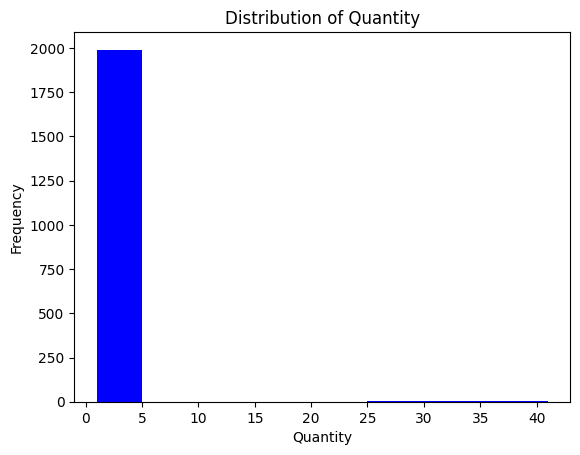

In [100]:
plt.hist(data["quantity"],bins=10,color="blue")
plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

**The histogram shows that most orders contain a small number of items , with the majority of quantities concentrated between 1 and 4 items , Only a few orders have much higher quantities, reaching up to 41 items, indicating the presence of a small number of unusually large orders**

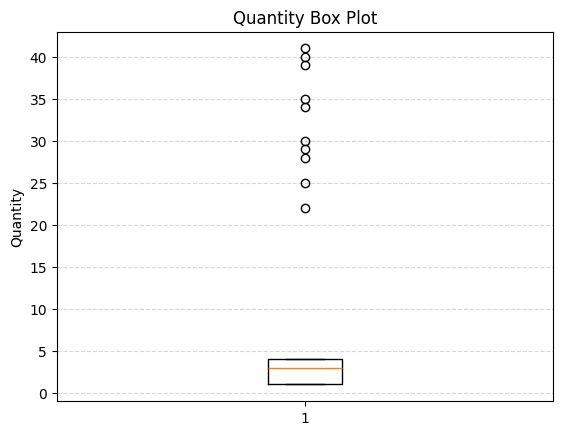

In [101]:
plt.boxplot(data["quantity"])
plt.title("Quantity Box Plot")
plt.ylabel("Quantity")
plt.grid(axis="y",linestyle="--",alpha=0.5)
plt.show()

**The box plot shows that most quantity values are concentrated within a small range. However, 10 potential outliers appear above the upper whisker , indicating a small number of unusually large orders**

In [102]:
data["delivery_time_minutes"].mean()

np.float64(35.4695)

**This code calculates the average delivery time in minutes for all orders**

In [103]:
data["delivery_time_minutes"].max()

292.0

**This code returns the maximum delivery time recorded in the dataset**

In [104]:
data["delivery_time_minutes"].min()

1.0

**This code returns the minimum delivery time recorded in the dataset**

**Average delivery Time:**
* **The average delivery time is approximately 35.47 minutes**

**Maximum Delivery Time:**
* **The maximum delivery time recorded is 292 minutes**

**Minmum Delivery Time:**
* **The minimum delivery time recorded is 1 minute**

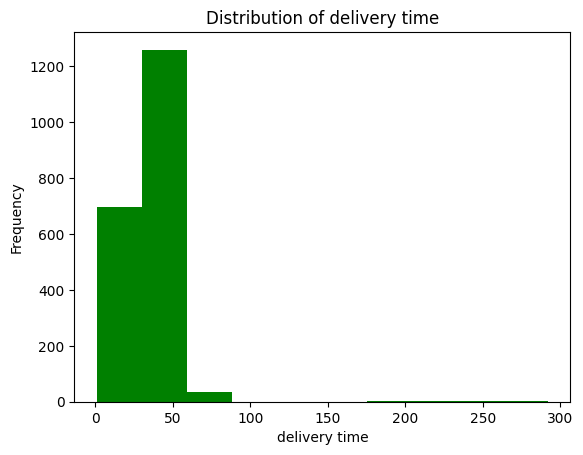

In [105]:
plt.hist(data["delivery_time_minutes"],bins=10,color="green")
plt.title("Distribution of delivery time")
plt.xlabel("delivery time")
plt.ylabel("Frequency")
plt.show()

**The histogram shows that most delivery times are concentrated between approximately 20 and 50 minutes , Only a few orders have significantly longer delivery times, extending up to 292 minutes , This indicates that the majority of deliveries are completed within a typical time range , while long delivery times are relatively uncommon**

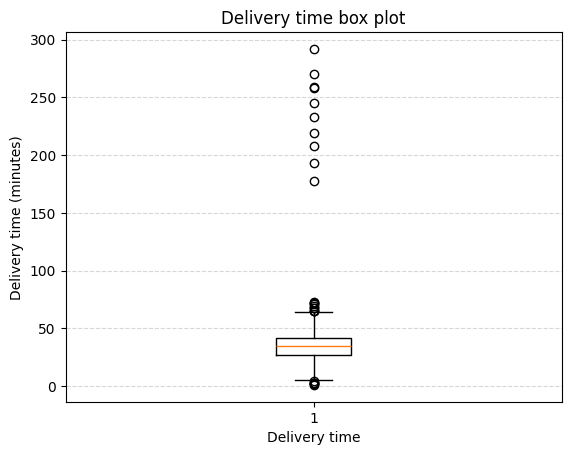

In [106]:
plt.boxplot(data["delivery_time_minutes"])
plt.title("Delivery time box plot")
plt.xlabel("Delivery time")
plt.ylabel("Delivery time (minutes)")
plt.grid(axis="y",linestyle="--",alpha=0.5)
plt.show()

**The box plot shows that most delivery times are concentrated between approximately 27 and 42 minutes. However , 26 potential outliers appear above the upper whisker , indicating a small number of orders with unusually long delivery times , reaching up to 292 minutes. These values were retained because they may represent real business situations rather than data entry errors**

In [107]:
data["price"].mean()

np.float64(172.035)

**Average Price**

**The average price of orders is approximately 172.04**

In [108]:
data["price"].max()

299

**Maximum Price**

**The highest price recorded in the dataset is 299**

In [109]:
data["price"].min()

50

**Minimum Price**

**The lowest price recorded in the dataset is 50**

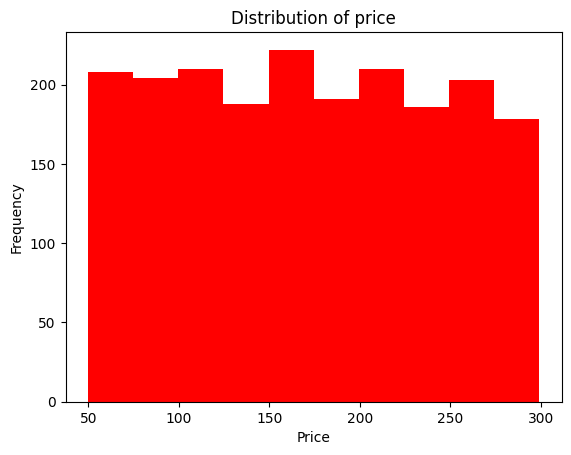

In [110]:
plt.hist(data["price"],bins=10,color="red")
plt.title("Distribution of price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


**The histogram shows that prices are distributed across the range from 50 to 299 , The frequencies are relatively similar across most price ranges , indicating that orders are fairly evenly distributed rather than concentrated in a specific price range**

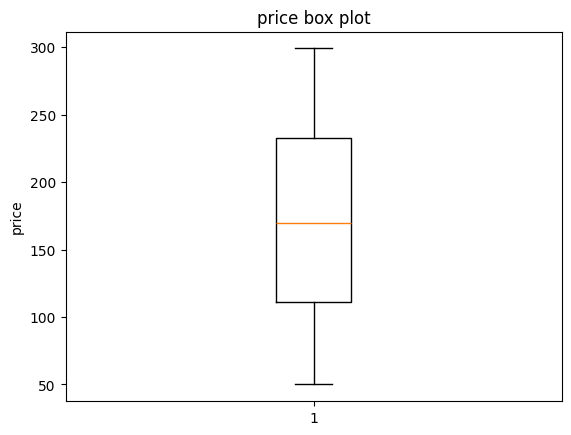

In [111]:
plt.boxplot(data["price"])
plt.title("price box plot")
plt.ylabel("price")
plt.show()

**The box plot shows that there are no outliers in the price column , The prices are distributed within a reasonable range , indicating a consistent pricing pattern across the dataset**

In [112]:
data["discount"].mean()

np.float64(14.5215)

**The average discount applied to orders is approximately 14.52**

In [113]:
data["discount"].max()

29

**The highest discount recorded in the dataset is 29**

In [114]:
data["discount"].min()

0

**The lowest discount recorded in the dataset is 0 , indicating that some orders were placed without any discount**

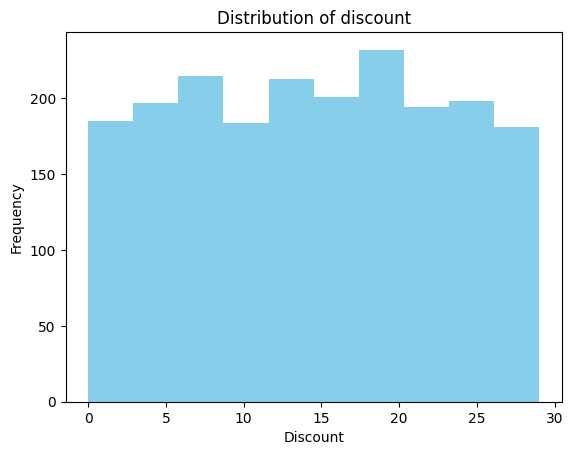

In [115]:
plt.hist(data["discount"],bins=10,color="skyblue")
plt.title("Distribution of discount")
plt.xlabel("Discount")
plt.ylabel("Frequency")
plt.show()

**The histogram shows that discounts are distributed across the range from 0 to 29  , The frequencies are relatively similar across most discount values , indicating that discounts are fairly evenly distributed rather than concentrated at a specific value**

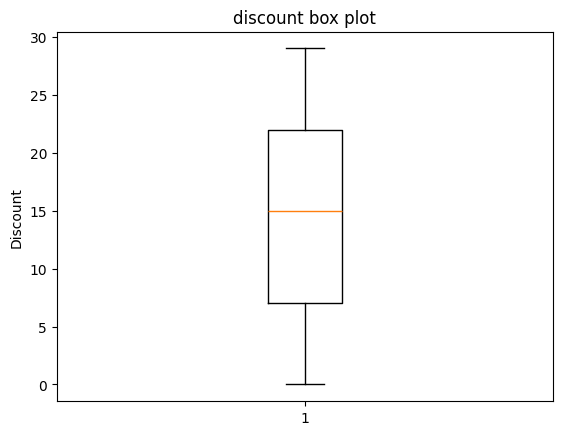

In [116]:
plt.boxplot(data["discount"])
plt.title("discount box plot")
plt.ylabel("Discount")
plt.show()

**The box plot shows that there are no outliers in the discount column , The discount values are distributed within a reasonable range from 0 to 29 , indicating a consistent discount pattern across the dataset**

In [117]:
data["rating"].mean()

np.float64(2.9825)

**The average customer rating is approximately 2.98**

In [118]:
data["rating"].max()

5.0

**The highest customer rating recorded in the dataset is 5**

In [119]:
data["rating"].min()

1.0

**The lowest customer rating recorded in the dataset is 1**

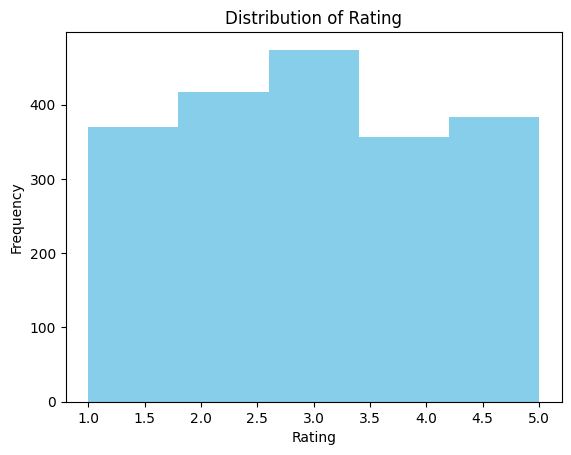

In [120]:
plt.hist(data["rating"],bins=5,color="skyblue")
plt.title("Distribution of Rating")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

**The histogram illustrates the distribution of ratings in the dataset. The x-axis represents the rating values (1 to 5), while the y-axis shows the frequency of each rating. The chart indicates that rating 3 has the highest frequency, making it the most common rating among the observations. Ratings 2 and 5 have moderate frequencies, whereas ratings 1 and 4 occur slightly less often. Overall, the distribution appears relatively balanced, with a noticeable peak at the middle rating, suggesting that most responses are centered around a rating of 3**

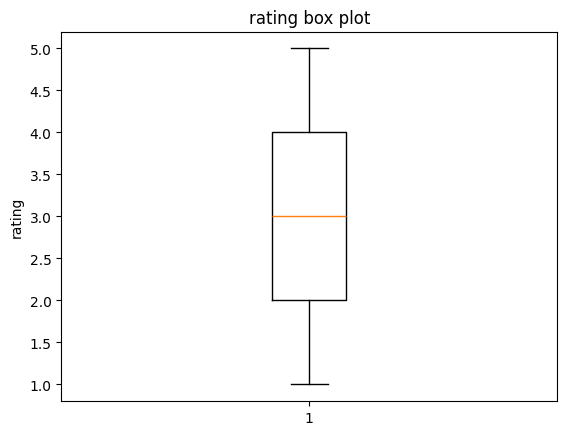

In [121]:
plt.boxplot(data["rating"])
plt.title("rating box plot")
plt.ylabel("rating")
plt.show()

**The box plot summarizes the distribution of the rating variable. The median rating is 3, indicating that half of the observations are below 3 and half are above it. The interquartile range (IQR) extends from 2 to 4, showing that the middle 50% of the ratings fall within this range. The whiskers extend from 1 to 5, representing the minimum and maximum ratings. No outliers are visible, suggesting that the ratings are evenly distributed without any extreme values. Overall, the ratings show a balanced spread centered around the median value of 3**

In [122]:
data["restaurant"].value_counts()

,count
restaurant,
Kebab House,424
Pasta Point,415
Pizza Hub,393
Burger Town,387
Sushi World,381


**Displays the number of orders for each restaurant, helping identify the restaurants with the highest and lowest number of orders**

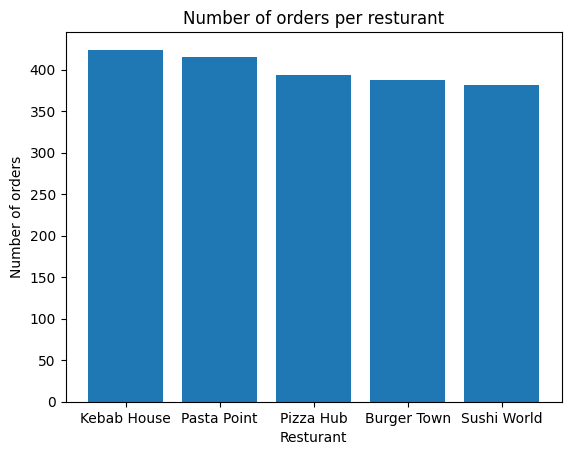

In [123]:
restaurant_counts=data["restaurant"].value_counts()
plt.bar(restaurant_counts.index,restaurant_counts.values)
plt.title("Number of orders per resturant")
plt.xlabel("Resturant")
plt.ylabel("Number of orders")
plt.show()

**The bar chart shows the number of orders for each restaurant , It helps identify the most popular restaurant with the highest number of orders and the least popular restaurant with the lowest number of orders**

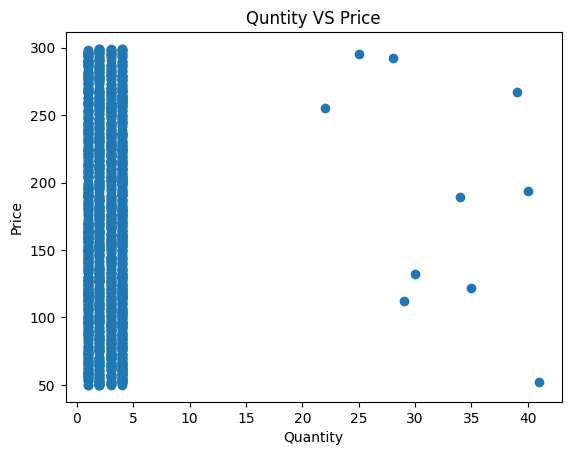

In [124]:
plt.scatter(data["quantity"],data["price"])
plt.title("Quntity VS Price")
plt.xlabel("Quantity")
plt.ylabel("Price")
plt.show()

Scatter Plot (Quantity vs Price) :
The scatter plot illustrates the relationship between Quantity and Price , Most data points are concentrated at low quantity values (between 1 and 4) , while the prices vary widely from approximately 50 to 300 , A few observations have higher quantity values (around 22 to 41) , but they are relatively rare and also show varying prices. Overall, there is no clear positive or negative correlation between quantity and price, indicating a weak relationship between the two variables

In [125]:
data["payment_method"].value_counts()

,count
payment_method,
Wallet,680
Cash,663
Card,657


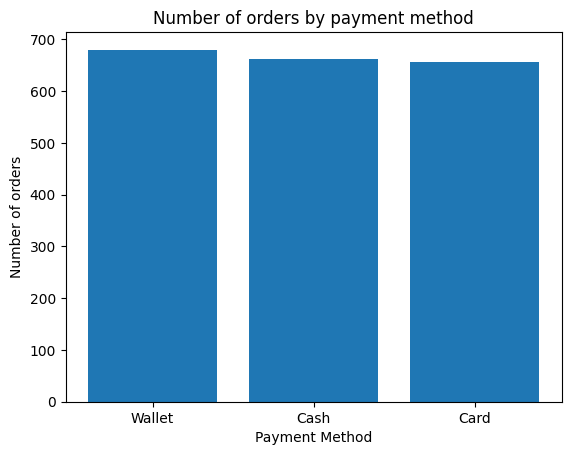

In [126]:
payment_counts=data["payment_method"].value_counts()
plt.bar(payment_counts.index,payment_counts.values)
plt.title("Number of orders by payment method")
plt.xlabel("Payment Method")
plt.ylabel("Number of orders")
plt.show()

**Bar Chart (Number of Orders by Payment Method):
The bar chart shows the number of orders for each payment method: Wallet, Cash, and Card. The three payment methods have very similar numbers of orders, indicating that customers use all payment options at nearly the same rate. Wallet has the highest number of orders, while Card has the lowest, but the differences are minimal. This suggests that there is no significant preference for one payment method over the others**

In [127]:
data["city"].value_counts()

,count
city,
Cairo,957
Alex,641
Giza,302
Unknown,100


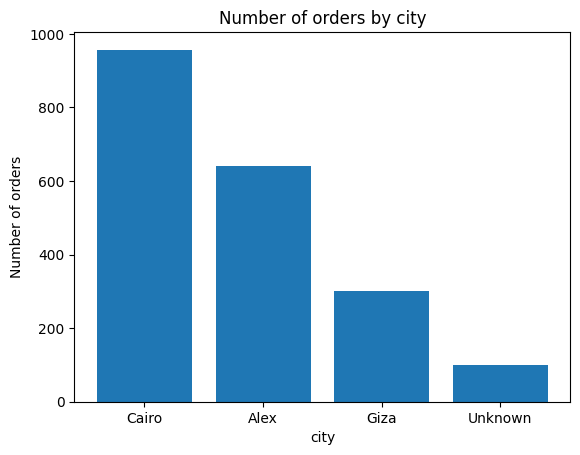

In [128]:
city_counts=data["city"].value_counts()
plt.bar(city_counts.index,city_counts.values)
plt.title("Number of orders by city")
plt.xlabel("city")
plt.ylabel("Number of orders")
plt.show()


**Bar Chart (Number of Orders by City):**

**The bar chart shows the distribution of orders by city. Cairo has the highest number of orders, followed by Alex, and then Giza. The "Unknown" category does not represent an actual city. Instead, it refers to missing values in the City column that were replaced with "Unknown" during the data cleaning process. This indicates that some orders did not have city information in the original dataset**

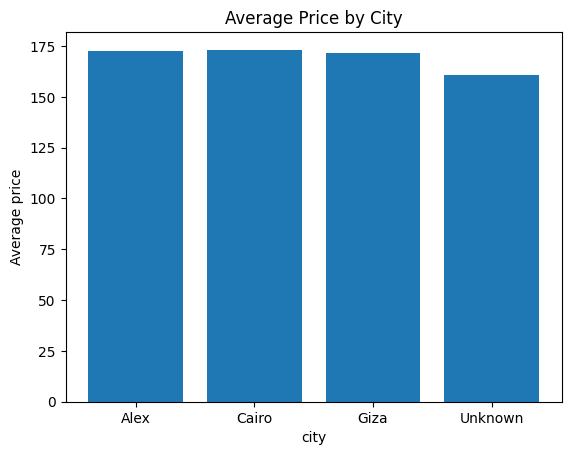

In [129]:
city_price= data.groupby("city")["price"].mean()
plt.bar(city_price.index, city_price.values)
plt.title("Average Price by City")
plt.xlabel("city")
plt.ylabel("Average price")
plt.show()

**Bar Chart (Average Price by City):**

**The bar chart compares the average price across different cities. The average prices in Cairo, Alex, and Giza are very similar, indicating that there is no significant difference in average prices among these cities. The "Unknown" category has a slightly lower average price. It is important to note that "Unknown" is not an actual city; it represents missing values in the City column that were replaced with "Unknown" during the data cleaning process**

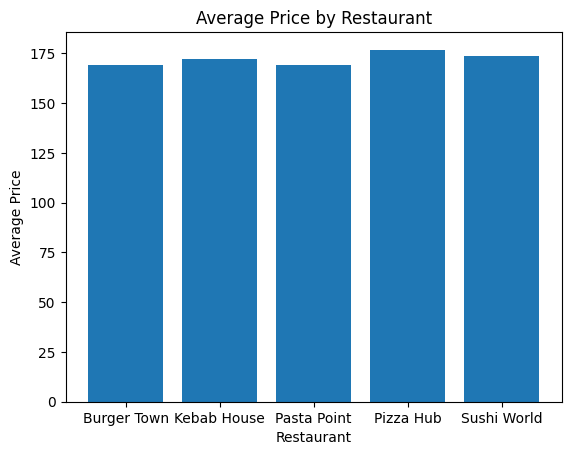

In [130]:
restaurant_price = data.groupby("restaurant")["price"].mean()
plt.bar(restaurant_price.index, restaurant_price.values)
plt.title("Average Price by Restaurant")
plt.xlabel("Restaurant")
plt.ylabel("Average Price")
plt.show()

**Bar Chart (Average Price by Restaurant):**

**The bar chart compares the average price across different restaurants. The average prices are very similar, ranging from approximately 170 to 176. Pizza Hub has the highest average price, while Burger Town and Pasta Point have slightly lower average prices. Overall, the differences in average prices among the restaurants are minimal, indicating that they offer food at similar price levels**

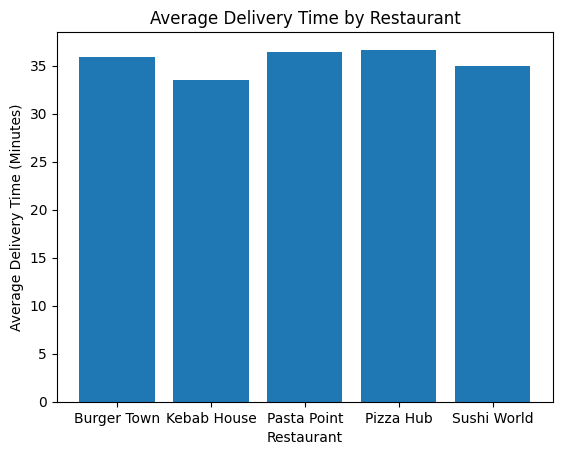

In [131]:
restaurant_delivery_time = data.groupby("restaurant")["delivery_time_minutes"].mean()
plt.bar(restaurant_delivery_time.index, restaurant_delivery_time.values)
plt.title("Average Delivery Time by Restaurant")
plt.xlabel("Restaurant")
plt.ylabel("Average Delivery Time (Minutes)")
plt.show()

**Bar Chart (Average Delivery Time by Restaurant):**

**The bar chart compares the average delivery time for different restaurants. The average delivery times are very similar, ranging from approximately 34 to 37 minutes. Pizza Hub has the highest average delivery time , followed closely by Pasta Point and Burger Town, while Kebab House has the lowest average delivery time. Overall , the differences between the restaurants are small, indicating that they provide delivery services with similar efficiency**

In [132]:
data["total_price"] = data["price"] * data["quantity"]
data[["price", "quantity", "total_price"]].head()

,price,quantity,total_price
0,265,4,1060
1,241,2,482
2,240,3,720
3,269,3,807
4,129,1,129


**Feature Engineering:**
**A new feature called total_price was created by multiplying the price by the quantity , This feature represents the total cost of each order and can be used for further analysis and insights into customer spending**

#Step 1: Interpret Results & Generate Insights
Key Findings
1. Most orders contain small quantities
Supporting Evidence:
The quantity distribution shows that most orders contain between 1 and 4 items, while only a few orders have much larger quantities.

**Insight:**

Customers usually place small orders, which is typical for food delivery services. Large orders are uncommon and may represent group or family purchases.

**Business Impact:**

Marketing campaigns and meal bundles should focus primarily on small individual orders while offering special promotions for bulk orders.

#2. Delivery performance is generally consistent

**Supporting Evidence:**

The average delivery time is approximately 35 minutes, and the average delivery time across restaurants ranges from 34 to 37 minutes.

**Insight:**

All restaurants provide similar delivery performance with only minor differences.

**Business Impact:**

The company maintains a consistent delivery service, although a small number of delayed deliveries should still be investigated

#3. Prices are similar across restaurants and cities

**Supporting Evidence:**

Average prices range between 170 and 176, with only small differences among restaurants and cities.

**Insight:**

Pricing appears standardized across the business.

**Business Impact:**

Customers receive similar pricing regardless of restaurant or city, helping maintain pricing fairness.

#4. Payment methods are equally preferred

**Supporting Evidence:**
Wallet, Cash, and Card have nearly identical numbers of orders.

**Insight:**
Customers are comfortable using all available payment methods.

**Business Impact:**
The company should continue supporting all payment options equally.

#5. Cairo generates the largest number of orders

**Supporting Evidence:**

Cairo recorded the highest number of orders, followed by Alexandria and Giza.

**Insight:**
Customer demand is concentrated in Cairo.

**Business Impact:**
Marketing efforts and operational resources should prioritize Cairo while expanding demand in other cities.

#6. Data quality improved after cleaning

**Supporting Evidence:**

Duplicates were removed, missing values were handled, inconsistent city names were standardized, and a new feature (total_price) was created.

**Insight:**

The cleaned dataset provides reliable information for decision-making.

**Business Impact:**

Business decisions can now rely on more accurate and consistent data.

#Step 2: Answer Analysis Objectives
**Objective 1**

Analyze the company's overall business performance.

**Findings:**

Average order price is about 172.
Average delivery time is 35 minutes.
Customer ratings average around 3 out of 5.

Answer:
The company demonstrates stable operational performance with consistent pricing and delivery times, although customer satisfaction has room for improvement.

**Objective 2**

Identify the most popular restaurants.

**Findings:**
Restaurant order counts were compared using a bar chart.

Answer:
Restaurant popularity differs based on the number of orders, allowing the business to identify its strongest-performing restaurants.

**Objective 3**

Understand customer ordering behavior.

Findings:

Most customers order between 1 and 4 items.
Payment methods are used almost equally.
Cairo has the highest customer activity.

**Answer:**

Customers generally place small orders, use all payment methods similarly, and most demand comes from Cairo.

Objective 4

Evaluate delivery speed and efficiency.

**Findings:**

Average delivery time is approximately 35 minutes, with only small differences between restaurants.

**Answer:**
Delivery performance is consistent across restaurants, although a few extreme delays should be monitored.

#Step 3: Business Recommendations
Recommendation 1

Focus marketing campaigns on Cairo, where customer demand is highest.

**Supporting Evidence**
Cairo has the largest number of orders.

**Expected Impact**
Higher sales and improved customer engagement.

**Recommendation 2**

Offer promotions designed for small orders.

**Supporting Evidence**

Most customers purchase between 1 and 4 items.

**Expected Impact**

Increase average order value.

**Recommendation 3**

Investigate delayed deliveries.

**Supporting Evidence**

Several delivery time outliers were detected.

**Expected Impact**

Improve customer satisfaction and service quality.

**Recommendation 4**

Maintain all payment methods.

Supporting Evidence
Customers use Wallet, Cash, and Card at similar rates.

**Expected Impact**
Provide flexibility and maintain customer convenience.

**Recommendation 5**

Use the new total_price feature to analyze customer spending and design personalized promotions.

**Supporting Evidence**
Feature engineering created the total_price variable.

**Expected Impact**
Better customer segmentation and improved marketing decisions.

#Step 4: Final Conclusion

This project analyzed a food delivery dataset by performing data cleaning, preprocessing, exploratory data analysis, and feature engineering. The analysis revealed that most customers place small orders, delivery times are generally consistent, prices are similar across restaurants and cities, and Cairo generates the highest number of orders. The dataset was successfully cleaned by removing duplicates, handling missing values, standardizing inconsistent data, and creating a new total_price feature. Based on these findings, recommendations include focusing marketing efforts on Cairo, improving delayed deliveries, maintaining multiple payment options, and using customer spending data to support future business decisions. Overall, the project provided valuable insights that can help improve operational efficiency, customer satisfaction, and business performance